In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/train.csv", index_col=False)
df = df.drop(columns="id")

In [5]:
print(df.shape)
print(df.duplicated().sum())
df.info()

(577347, 11)
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 48.5+ MB


In [14]:
df.head(10)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


#### Takeaways:
- The dataset is large, with 577,347 rows and 11 columns after dropping 'id'.
- There are no duplicate rows.
- The input data contains 8 numeric features and 2 categorical features.
- The target variable, 'class', is categorical and will be modeled as a multiclass classification problem.

#### Check target class distribution

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

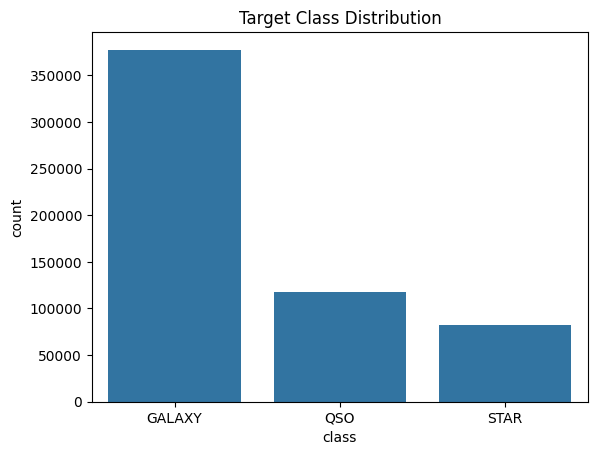

In [7]:
class_counts = df['class'].value_counts()
class_proportions = df['class'].value_counts(normalize=True)

display(class_counts)
display(class_proportions)

sns.countplot(data=df, x="class")
plt.title("Target Class Distribution")
plt.show()

#### Takeaways:
- The target is moderately imbalanced: GALAXY makes up 65% of the training data.
- Future train/validation splits should use stratification to preserve class proportions.
- Accuracy alone may be misleading, so log loss and class-level performance should be checked.

#### Categorical Features vs Target



In [13]:
display(pd.crosstab(df["spectral_type"], df["class"], normalize="index"))
pd.crosstab(df["galaxy_population"], df["class"], normalize="index")

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,0.198490,0.503709,0.297801
G/K,0.567750,0.192739,0.239511
M,0.949559,0.012821,0.037620
O/B,0.082803,0.710836,0.206361


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345106,0.420022,0.234873
Red_Sequence,0.902846,0.027753,0.069401


#### Takeaways:
- `spectral_type` appears strongly related to the target. For example M-type observations are mostly GALAXY where as O/B are mostly QSO.
- `galaxy_population`'s Red_sequence is greatly skewed towards GALAXY, whilst Blue_Cloud is more mixed.
- Both features show great potential as predictors.

#### Numeric Feature Averages by Target Class

In [11]:
df.groupby("class")[['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']].mean()

,alpha,delta,u,g,r,i,z,redshift
class,,,,,,,,
GALAXY,178.557241,21.033443,22.989160,21.270147,19.860511,19.068222,18.629897,0.509026
QSO,189.665998,25.811829,21.724756,21.160314,20.918809,20.767309,20.602139,1.875641
STAR,184.178832,19.858725,20.960388,19.591033,19.075853,18.830555,18.707180,0.068115


#### Takeaways:
- `red_shift` differs substantially by class, especially QSO compared to GALAXY and STAR.
- Further insights need visualizations of distributions.

#### Correlation Heatmap

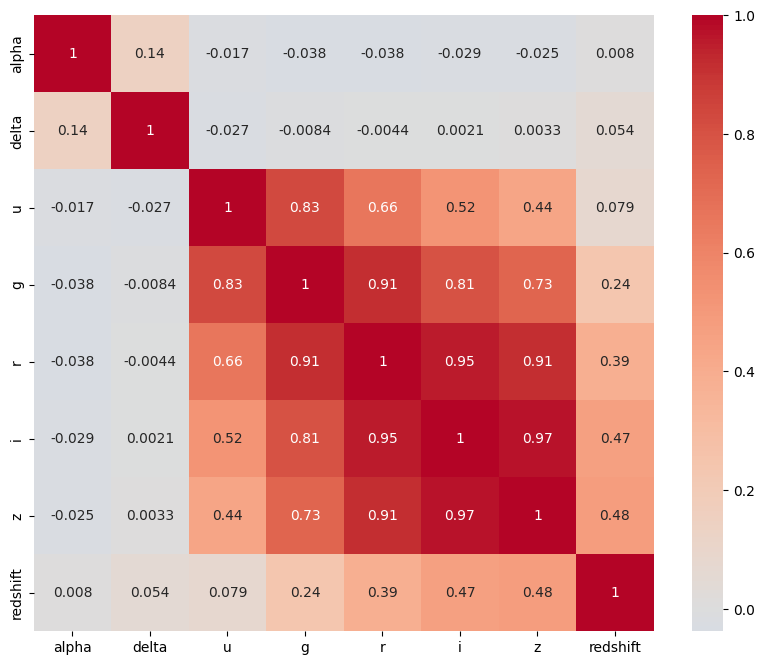

In [12]:
numeric_cols = df.select_dtypes("number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

#### Takeaways:
- `alpha` and `delta` appear to be slightly correlated with eachother however are both uncorrelated to other numerical features.
- The photometric bands are highly correlated, especially `r`, `i` and `z`. This suggests an ablation study of the photometric bands is worthwhile. 
